In [1]:
# Import required libraries
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
df['target'] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# Check the shape of the dataset
print("Shape of dataset:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

Shape of dataset: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Number of duplicate rows: 1


In [4]:
# Count the number of flowers in each class
print("Number of flowers in each class:")
print(df['target'].value_counts().sort_index())

Number of flowers in each class:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
# Statistical summary of the Iris dataset
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


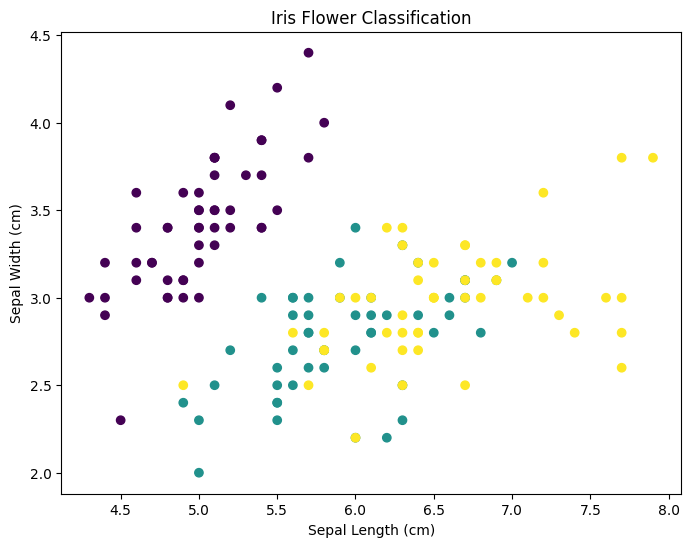

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
    c=df['target']
)

plt.title('Iris Flower Classification')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

plt.show()

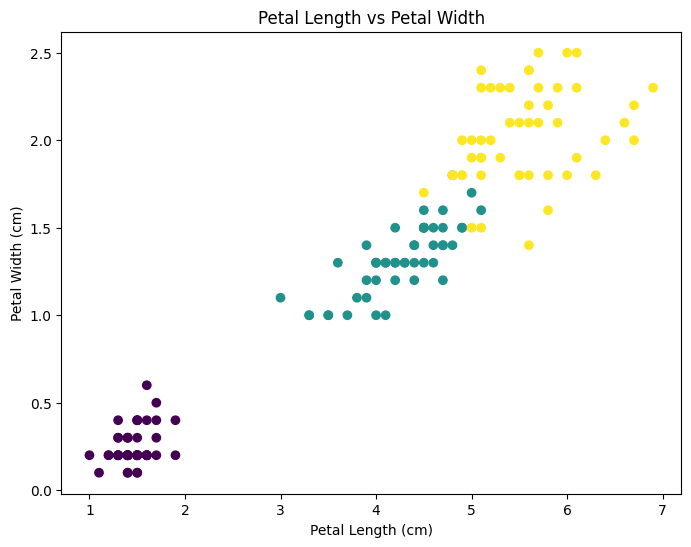

In [7]:
# Petal length vs Petal width

plt.figure(figsize=(8, 6))

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)'],
    c=df['target']
)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

plt.show()

In [8]:
# Define features and target

X = df[
    [
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)'
    ]
]

y = df['target']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [10]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [11]:
# Predict flower classes using the test data
y_pred = model.predict(X_test)

print("Predicted Classes:")
print(y_pred)

Predicted Classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [12]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 93.33 %


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


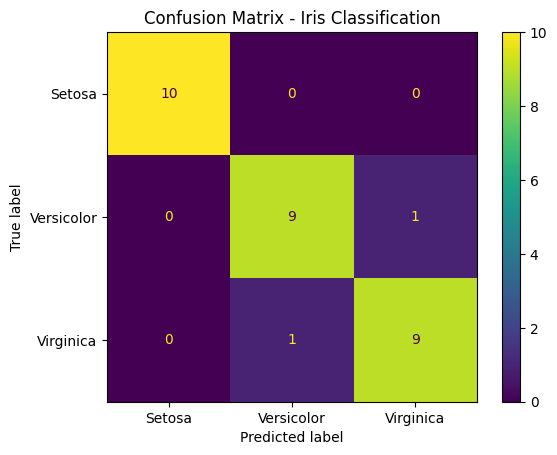

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Setosa', 'Versicolor', 'Virginica']
)

disp.plot()
plt.title('Confusion Matrix - Iris Classification')
plt.show()

In [14]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



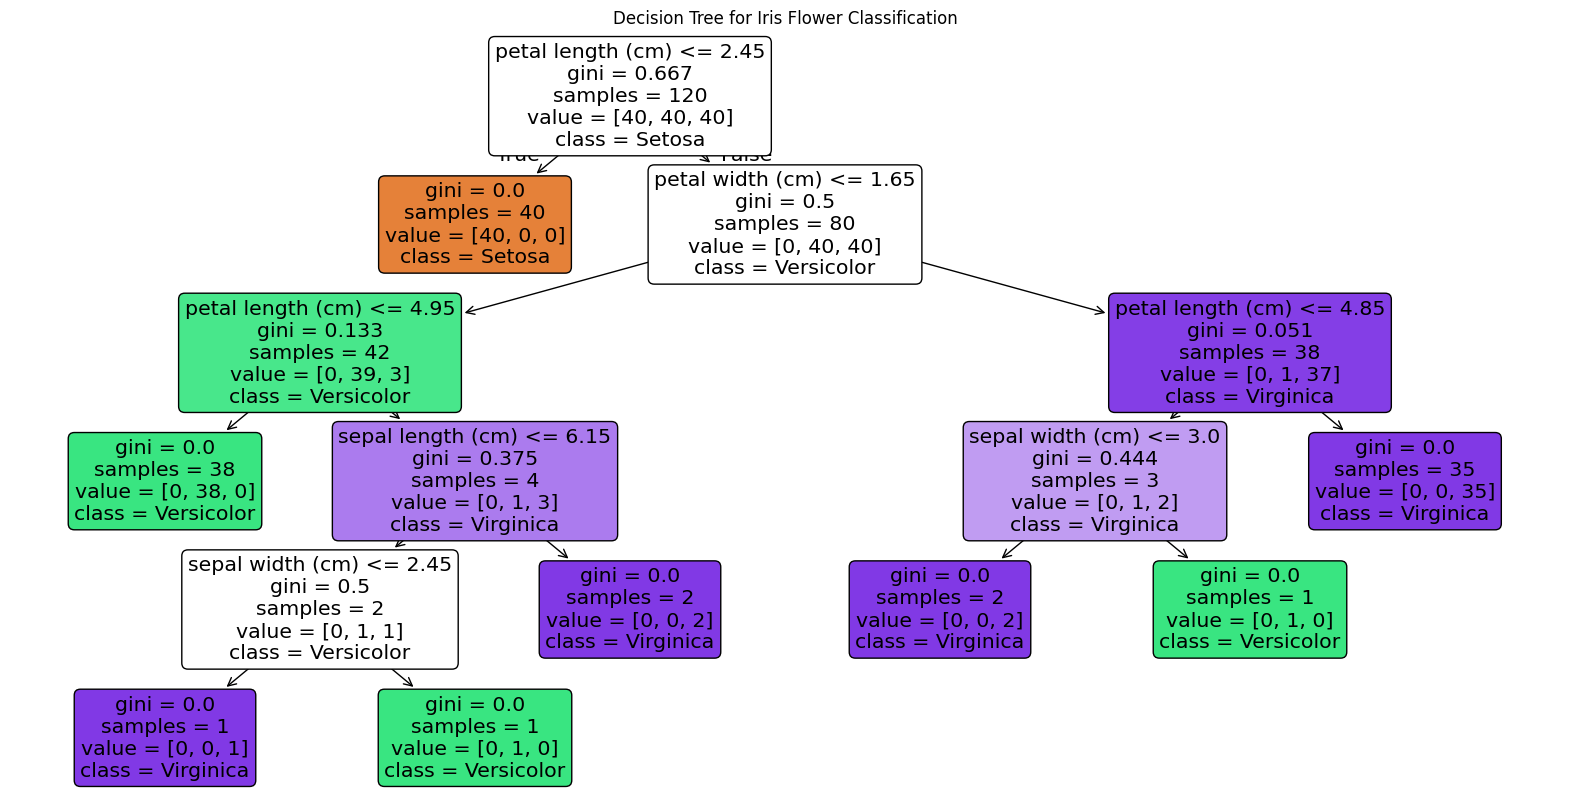

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Setosa', 'Versicolor', 'Virginica'],
    filled=True,
    rounded=True
)

plt.title('Decision Tree for Iris Flower Classification')
plt.show()

In [16]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.558568
3   petal width (cm)    0.406015
1   sepal width (cm)    0.029167
0  sepal length (cm)    0.006250


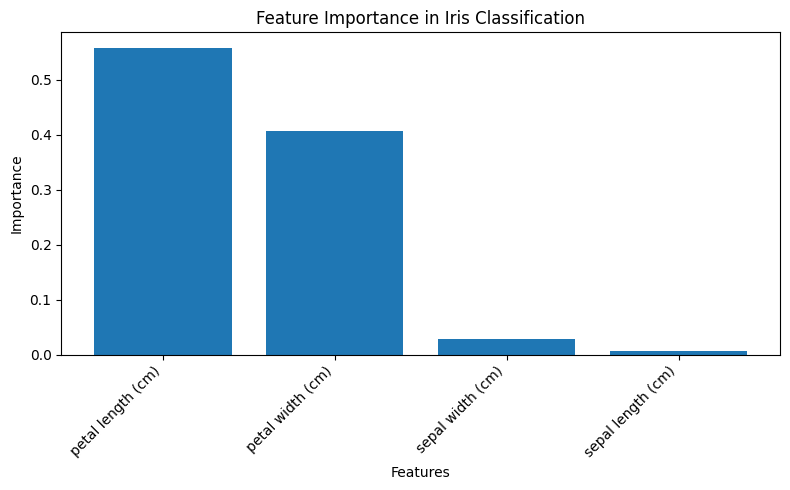

In [17]:
# Plot feature importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance in Iris Classification')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [18]:
# Final model summary

print("===== FINAL MODEL RESULTS =====")

print("Model: Decision Tree Classifier")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nFeature Importance:")
print(feature_importance)

===== FINAL MODEL RESULTS =====
Model: Decision Tree Classifier
Accuracy: 93.33 %

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.558568
3   petal width (cm)    0.406015
1   sepal width (cm)    0.029167
0  sepal length (cm)    0.006250


In [19]:
print("===== FINAL MODEL RESULTS =====")

print("Model: Decision Tree Classifier")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nFeature Importance:")
print(feature_importance)

===== FINAL MODEL RESULTS =====
Model: Decision Tree Classifier
Accuracy: 93.33 %

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.558568
3   petal width (cm)    0.406015
1   sepal width (cm)    0.029167
0  sepal length (cm)    0.006250


Observations
The Decision Tree Classifier achieved an accuracy of 93.33%, showing good performance in classifying the Iris flowers.
The model classified the flowers into three classes: Setosa, Versicolor, and Virginica.
Petal length was the most important feature, with an importance of 0.558568.
Petal width was the second most important feature, with an importance of 0.406015.
Sepal width had a lower importance of 0.029167, while sepal length had the lowest importance of 0.006250.
The confusion matrix and classification report were used to evaluate the model's classification performance.

Conclusion

The Iris flower classification project used Python and machine learning to classify flowers into three species: Setosa, Versicolor, and Virginica. The Iris dataset was explored and prepared before training a Decision Tree Classifier. The model was evaluated using accuracy, a confusion matrix, and a classification report. Feature importance was also analyzed to understand which measurements contributed most to classification. The project demonstrates how machine learning can be applied to classify data and evaluate model performance.